In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
runs = 100
x = np.zeros((runs,10))
y = np.zeros((runs,10))

## No interaction between particles

In [3]:
delta = 0.01
r = [0]
m = [0]
for i in range(runs-1):
    x[i+1,:] = x[i,:] + np.sqrt(2)*delta*np.random.normal(0, 1,(10))
    y[i+1,:] = y[i,:] + np.sqrt(2)*delta*np.random.normal(0, 1,(10))
    Rcm = np.mean(np.sqrt(x[i+1,:]**2 + y[i+1,:]**2))
    R = np.sqrt(np.sum((np.sqrt(x[i+1,:]**2 + y[i+1,:]**2) - Rcm)**2)/runs)
    r.append(R)
    msd = np.mean((np.sqrt(x[i+1,:]**2 + y[i+1,:]**2) - np.sqrt(x[0,:]**2 + y[0,:]**2))**2)
    m.append(msd)

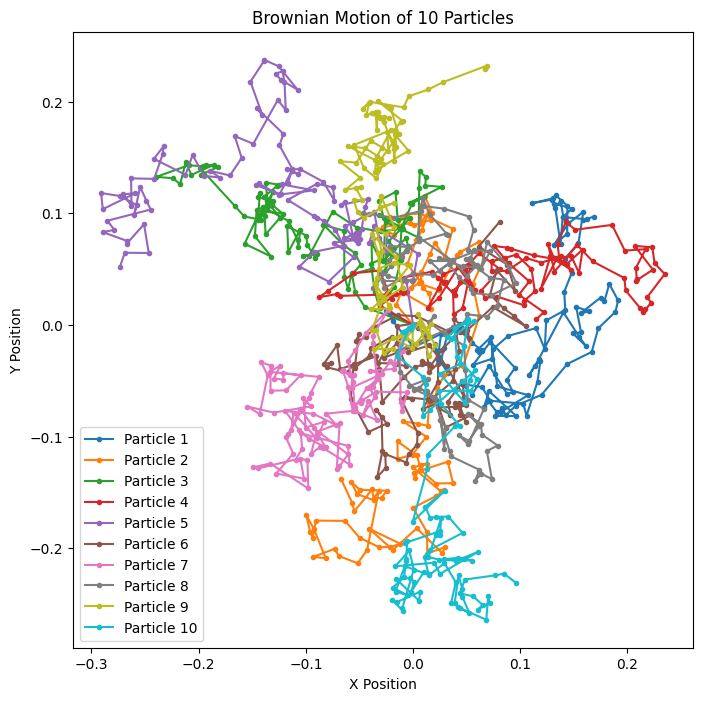

In [4]:
plt.figure(figsize=(8, 8))
for n in range(10):
    plt.plot(x[:,n], y[:,n],'.-', label=f"Particle {n+1}")

plt.title("Brownian Motion of 10 Particles")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()
plt.show()

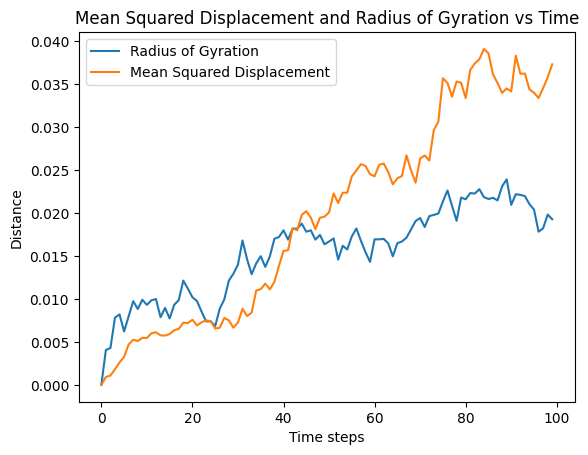

In [5]:
# plt.close()
# fig, ax = plt.subplots(2, 1,figsize=(6, 8))
# ax[0].plot(range(runs),r,'-', label=f"Radius of Gyration")
# ax[1].plot(range(runs),m,'-', label=f"Mean Squared Displacement")

# ax[1].set_title("Mean Squared Displacement vs Time")
# ax[1].set_xlabel("Time steps") 
# ax[1].set_ylabel("Mean Squared Displacement")
# ax[0].set_title("Radius of Gyration vs Time")
# ax[0].set_ylabel("Radius of Gyration")
# plt.show()

plt.plot(range(runs),r,'-', label=f"Radius of Gyration")
plt.plot(range(runs),m,'-', label=f"Mean Squared Displacement")
plt.title("Mean Squared Displacement and Radius of Gyration vs Time")
plt.xlabel("Time steps")
plt.ylabel("Distance")
plt.legend()
plt.show()

## Lennard Jones interaction between particles
### Epsilon = 1.0

In [6]:
# Parameters
num_particles = 10  # Number of particles
runs = 1000         # Number of time steps
delta = 0.01        # Time step size
epsilon = 1.0       # Lennard-Jones potential depth
sigma = 1.0         # Lennard-Jones distance parameter
thermal_factor = np.sqrt(2) * delta  # Thermal motion scaling factor

def lennard_jones_force(positions,epsilon):
    num_particles = positions.shape[0]
    forces = np.zeros_like(positions)  # Initialize forces to zero

    for i in range(num_particles):
        for j in range(num_particles):
            if i == j:
                continue
            displacement = positions[i] - positions[j]
            distance = np.linalg.norm(displacement)
            
            if distance == 0 or distance < sigma:
                continue
            
            # Compute the Lennard-Jones force
            force_magnitude = 24 * epsilon * (2 * (sigma / distance)**13 - (sigma / distance)**7) / sigma
            # force_magnitude = 24 * epsilon * (-2 * (sigma / distance)**12 + (sigma / distance)**6 )
            forces[i] += force_magnitude * (displacement / distance)  # Add force contribution

    return forces


def simulate(num_particles, runs, delta, epsilon):
    r = [0]
    m = [0]
    # Initialize particle positions randomly in a 2D space
    np.random.seed(36)  # For reproducibility
    positions = (np.random.rand(num_particles, 2)-0.5) * 10  # Random positions in a 10x10 box

    # Initialize arrays to store trajectories
    trajectories_x = np.zeros((runs, num_particles))
    trajectories_y = np.zeros((runs, num_particles))
    trajectories_x[0, :] = positions[:, 0]
    trajectories_y[0, :] = positions[:, 1]

    # Simulation loop
    for t in range(1, runs):
        # Compute Lennard-Jones forces
        forces = lennard_jones_force(positions,epsilon)
        
        # Update positions with thermal motion and Lennard-Jones forces
        thermal_motion = thermal_factor * np.random.normal(0, 1, positions.shape)
        positions += thermal_motion - delta**2 * forces
        
        # Store trajectories
        trajectories_x[t, :] = positions[:, 0]
        trajectories_y[t, :] = positions[:, 1]

        Rcm = np.mean(np.sqrt(trajectories_x[t,:]**2 + trajectories_y[t,:]**2))
        R = np.sqrt(np.sum((np.sqrt(trajectories_x[t,:]**2 + trajectories_y[t,:]**2) - Rcm)**2)/runs)
        r.append(R)
        msd = np.mean((np.sqrt(trajectories_x[t,:]**2 + trajectories_y[t,:]**2) - np.sqrt(trajectories_x[0,:]**2 + trajectories_y[0,:]**2))**2)
        m.append(msd)
    return r, m, positions, trajectories_x, trajectories_y

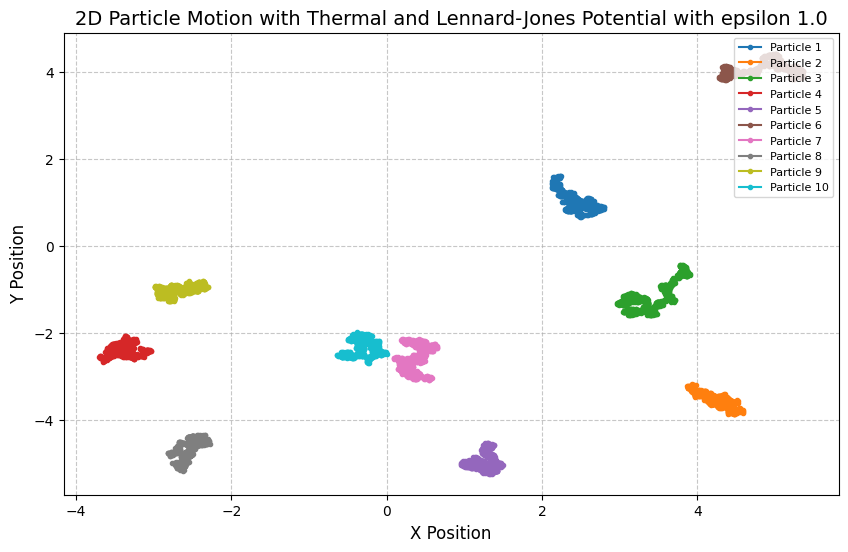

In [7]:
plt.close()
r, msd, positions, trajectories_x, trajectories_y = simulate(num_particles, runs, delta, epsilon)
# Plot the trajectories of particles
plt.figure(figsize=(10, 6))
for n in range(num_particles):
    plt.plot(trajectories_x[:, n], trajectories_y[:, n],".-", label=f"Particle {n + 1}")

plt.title(f"2D Particle Motion with Thermal and Lennard-Jones Potential with epsilon {epsilon}", fontsize=14)
plt.xlabel("X Position", fontsize=12)
plt.ylabel("Y Position", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right', fontsize=8)
# plt.xlim(-20,20)
# plt.ylim(-20,20)
plt.show()

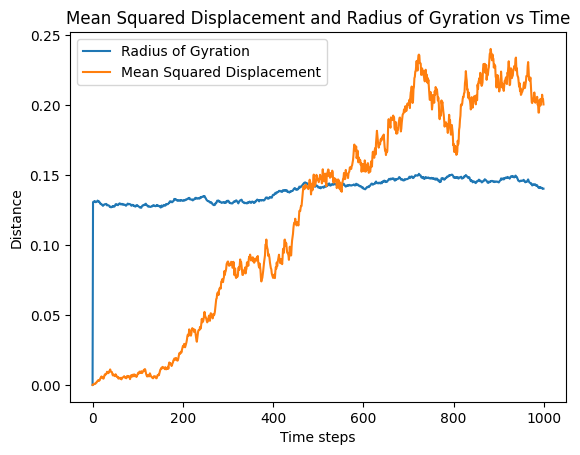

In [8]:
plt.plot(range(runs),r,'-', label=f"Radius of Gyration")
plt.plot(range(runs),msd,'-', label=f"Mean Squared Displacement")
plt.title("Mean Squared Displacement and Radius of Gyration vs Time")
plt.xlabel("Time steps")
plt.ylabel("Distance")
plt.legend()
plt.show()

### Epsilon = 0.1

In [9]:
epsilon = 0.1       # Lennard-Jones potential depth

r, msd, positions,trajectories_x,trajectories_y =  simulate(num_particles, runs, delta, epsilon)

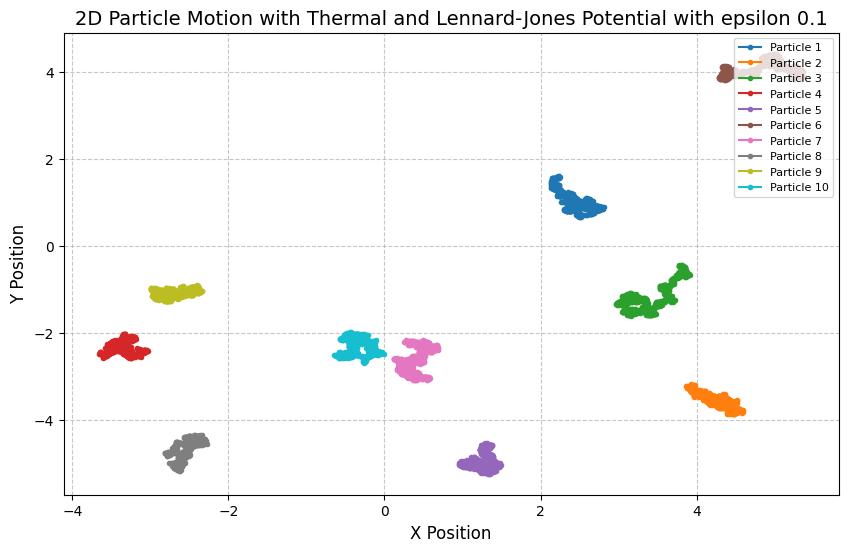

In [10]:
# Plot the trajectories of particles
plt.figure(figsize=(10, 6))
for n in range(num_particles):
    plt.plot(trajectories_x[:, n], trajectories_y[:, n],".-", label=f"Particle {n + 1}")

plt.title(f"2D Particle Motion with Thermal and Lennard-Jones Potential with epsilon {epsilon}", fontsize=14)
plt.xlabel("X Position", fontsize=12)
plt.ylabel("Y Position", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right', fontsize=8)
# plt.xlim(-20,20)
# plt.ylim(-20,20)
plt.show()

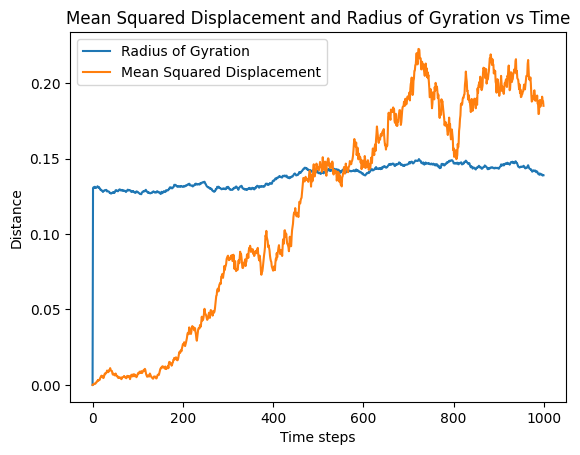

In [11]:
plt.plot(range(runs),r,'-', label=f"Radius of Gyration")
plt.plot(range(runs),msd,'-', label=f"Mean Squared Displacement")
plt.title("Mean Squared Displacement and Radius of Gyration vs Time")
plt.xlabel("Time steps")
plt.ylabel("Distance")
plt.legend()
plt.show()